In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os

# Cấu hình chung
os.makedirs('../figures', exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

# Thiết lập thông tin vị trí 
LAT = 10.823
LON = 106.6296
YEAR = 2024
LOCATION = "TP.HCM"

print("--- BẮT ĐẦU TẢI DỮ LIỆU ĐÃ THỐNG KÊ ---")

# 1. Tải Dữ liệu theo Ngày (Dùng cho Time Series, Correlation, Heatmap, Wind Rose)
daily_path = f'../processed/daily_weather_aqi_{LAT}_{LON}_{YEAR}.csv'
try:
    df_daily = pd.read_csv(daily_path)
    df_daily['date'] = pd.to_datetime(df_daily['date'])
    print(f"✅ Đã tải: {daily_path}")
except FileNotFoundError:
    print(f"❌ LỖI: Không tìm thấy file {daily_path}. Vui lòng chạy lại file 04_statistics_and_aggregation.ipynb.")
    # Tạo DataFrame rỗng để tránh lỗi code tiếp theo
    df_daily = pd.DataFrame() 

# 2. Tải Dữ liệu theo Tháng (Dùng cho So sánh monthly)
monthly_path = f'../processed/monthly_weather_aqi_{LAT}_{LON}_{YEAR}.csv'
try:
    df_monthly = pd.read_csv(monthly_path)
    print(f"✅ Đã tải: {monthly_path}")
except FileNotFoundError:
    df_monthly = pd.DataFrame()

--- BẮT ĐẦU TẢI DỮ LIỆU ĐÃ THỐNG KÊ ---
✅ Đã tải: ../processed/daily_weather_aqi_10.823_106.6296_2024.csv
✅ Đã tải: ../processed/monthly_weather_aqi_10.823_106.6296_2024.csv


Hình 1: Time Series (Meteogram).

C:\Users\Nguyen Duc Vu Bao\AppData\Local\Temp\ipykernel_9784\265661663.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


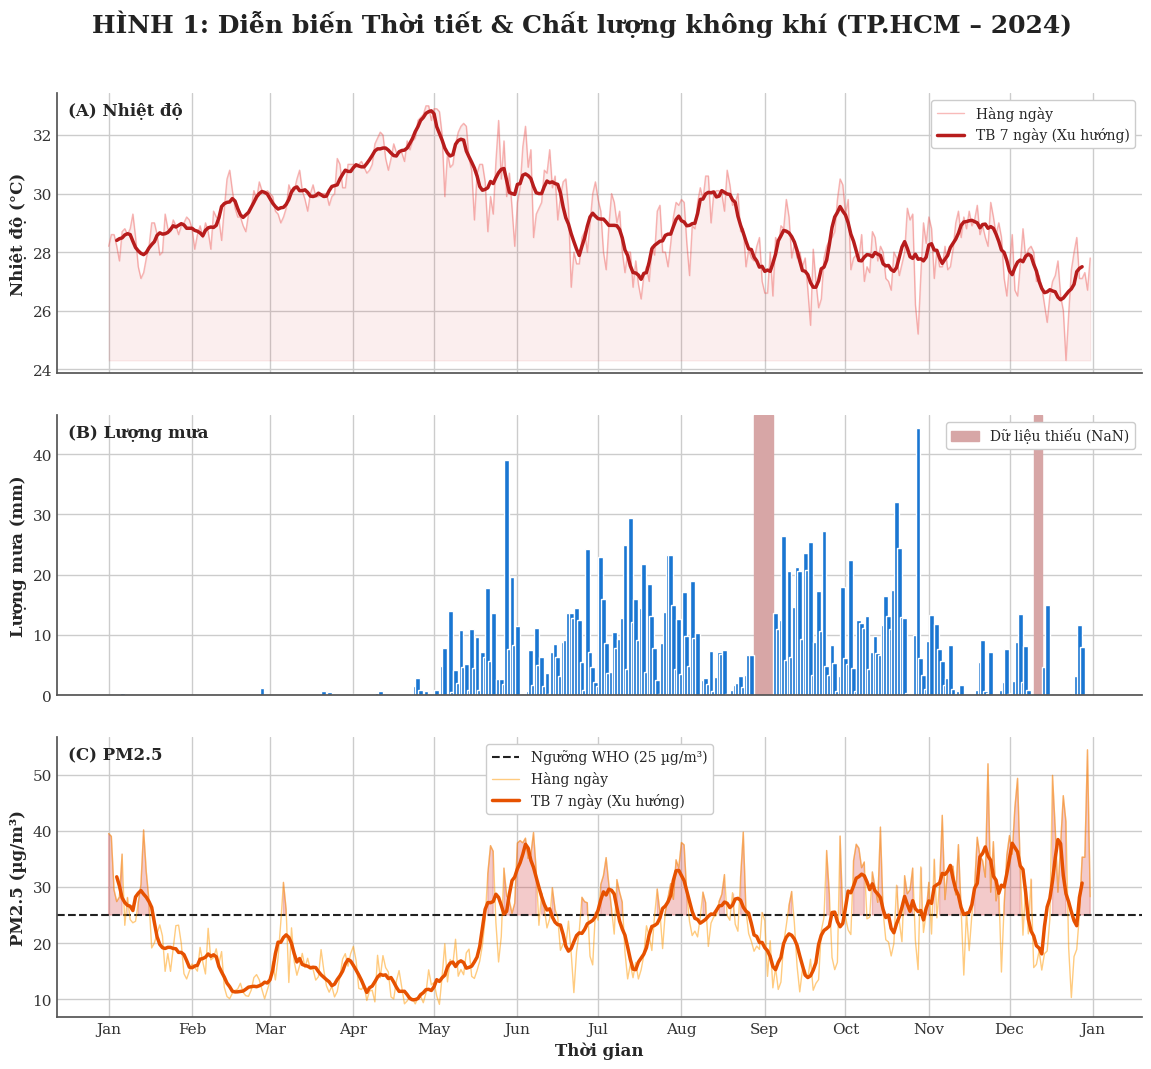

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np


plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#555555",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
   
    "legend.frameon": True, 
    "legend.facecolor": "white", 
    "legend.framealpha": 1.0, 
    "legend.edgecolor": "#cccccc",
    "legend.fontsize": 10
})

if not df_daily.empty:
    precip_col = 'precip_total' if 'precip_total' in df_daily.columns else 'precipitation_mm'
    

    df_daily['temp_roll'] = df_daily['temp_mean'].rolling(7, center=True).mean()
    df_daily['pm2_5_roll'] = df_daily['pm2_5_mean'].rolling(7, center=True).mean()


    nan_segments = []
    if precip_col in df_daily.columns:
        is_nan = df_daily[precip_col].isnull()
        nan_blocks = is_nan.diff().ne(0).cumsum()
        df_nan = df_daily[is_nan].copy()
        df_nan['block'] = df_nan.index.to_series().map(nan_blocks)
        
        for _, g in df_nan.groupby('block'):
            nan_segments.append((g['date'].min(), g['date'].max()))


    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1, figsize=(14, 12), sharex=True,
        gridspec_kw={'hspace': 0.15}
    )

    fig.suptitle(
        f'HÌNH 1: Diễn biến Thời tiết & Chất lượng không khí ({LOCATION} – {YEAR})',
        fontsize=18, fontweight='bold', y=0.95, color='#222222'
    )

 
    ax1.text(0.01, 0.92, "(A) Nhiệt độ", transform=ax1.transAxes, fontsize=12, fontweight="bold")
    ax1.fill_between(df_daily['date'], df_daily['temp_mean'].min(), df_daily['temp_mean'], 
                     color='#D32F2F', alpha=0.08)
    ax1.plot(df_daily['date'], df_daily['temp_mean'], color='#EF5350', lw=1, alpha=0.4, label="Hàng ngày")
    ax1.plot(df_daily['date'], df_daily['temp_roll'], color='#B71C1C', lw=2.5, label="TB 7 ngày (Xu hướng)")
    ax1.set_ylabel("Nhiệt độ (°C)", fontweight="bold")
    ax1.legend(loc='upper right')
    ax1.tick_params(direction='in')
    ax2.text(0.01, 0.92, "(B) Lượng mưa", transform=ax2.transAxes, fontsize=12, fontweight="bold")
    if precip_col in df_daily.columns:
        first = True
        for start, end in nan_segments:
            ax2.axvspan(start, end, color="#D7A6A6", alpha=1.0, 
                        label="Dữ liệu thiếu (NaN)" if first else None)
            first = False
        ax2.bar(df_daily['date'], df_daily[precip_col], color='#1976D2', width=1.8)
        ax2.set_ylabel("Lượng mưa (mm)", fontweight="bold")
        ax2.set_ylim(bottom=0)
        ax2.tick_params(direction='in')
        if nan_segments:
            ax2.legend(loc='upper right')

  
    ax3.text(0.01, 0.92, "(C) PM2.5", transform=ax3.transAxes, fontsize=12, fontweight="bold")
    ax3.axhline(25, color="#212121", ls="--", lw=1.5, label="Ngưỡng WHO (25 µg/m³)")
    ax3.plot(df_daily['date'], df_daily['pm2_5_mean'], color="#FF9800", lw=1, alpha=0.5, label="Hàng ngày")
    ax3.plot(df_daily['date'], df_daily['pm2_5_roll'], color="#E65100", lw=2.5, label="TB 7 ngày (Xu hướng)")
    ax3.fill_between(df_daily['date'], df_daily['pm2_5_mean'], 25, 
                     where=(df_daily['pm2_5_mean'] > 25), color="#D32F2F", alpha=0.25)
    ax3.set_ylabel("PM2.5 (µg/m³)", fontweight="bold")
    ax3.set_xlabel("Thời gian", fontweight="bold")
    ax3.legend(loc="best", ncol=1) 
    ax3.tick_params(direction='in')
    ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax3.xaxis.set_major_locator(mdates.MonthLocator())


    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("../figures/01_time_series.pdf", format="pdf", dpi=300, bbox_inches="tight")
    plt.show()

    


HÌNH 2:UV Index Time Series

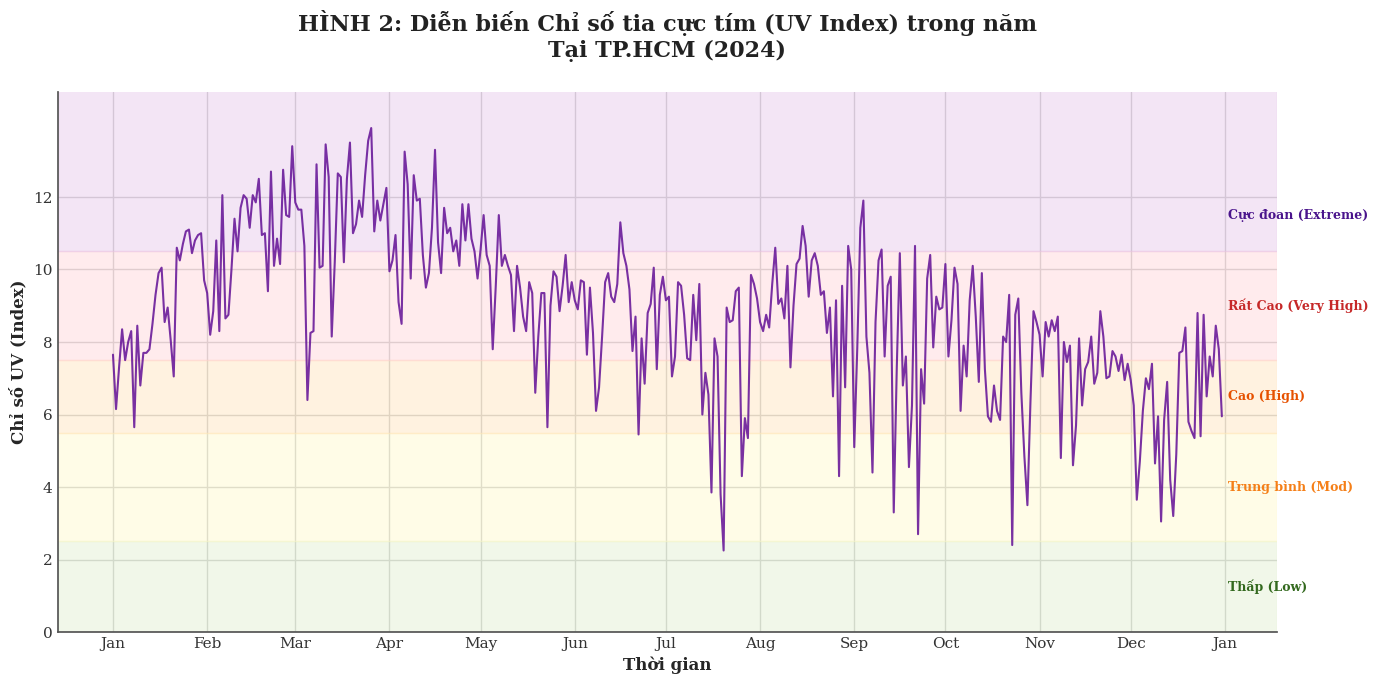

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# --- 1. CẤU HÌNH GIAO DIỆN ---
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#555555"
})

if not df_daily.empty:
    
    uv_col = 'uv_max' if 'uv_max' in df_daily.columns else 'uv_index_max'
    
    if uv_col in df_daily.columns:
       
        fig, ax = plt.subplots(figsize=(14, 7))

        
        ax.axhspan(0, 2.5, color='#DCEDC8', alpha=0.4, label='Thấp') 
        ax.axhspan(2.5, 5.5, color='#FFF9C4', alpha=0.4, label='Trung bình')
        ax.axhspan(5.5, 7.5, color='#FFE0B2', alpha=0.4, label='Cao')
        ax.axhspan(7.5, 10.5, color='#FFCDD2', alpha=0.4, label='Rất cao')
        ax.axhspan(10.5, 15, color='#E1BEE7', alpha=0.4, label='Cực đoan')

     
        ax.plot(df_daily['date'], df_daily[uv_col], 
                color='#6A1B9A', lw=1.5, alpha=0.9, 
                label='UV Index (Max Daily)')

     
        x_end = df_daily['date'].max()
        offset = pd.Timedelta(days=2)
        
        ax.text(x_end + offset, 1.25, 'Thấp (Low)', color='#33691E', fontsize=9, va='center', fontweight='bold')
        ax.text(x_end + offset, 4, 'Trung bình (Mod)', color='#F57F17', fontsize=9, va='center', fontweight='bold')
        ax.text(x_end + offset, 6.5, 'Cao (High)', color='#E65100', fontsize=9, va='center', fontweight='bold')
        ax.text(x_end + offset, 9, 'Rất Cao (Very High)', color='#C62828', fontsize=9, va='center', fontweight='bold')
        ax.text(x_end + offset, 11.5, 'Cực đoan (Extreme)', color='#4A148C', fontsize=9, va='center', fontweight='bold')

        ax.set_title(f'HÌNH 2: Diễn biến Chỉ số tia cực tím (UV Index) trong năm\nTại {LOCATION} ({YEAR})', 
                     fontsize=16, fontweight='bold', y=1.05, color='#222222')
        
        ax.set_ylabel('Chỉ số UV (Index)', fontweight='bold')
        ax.set_xlabel('Thời gian', fontweight='bold')
        
        y_max = df_daily[uv_col].max()
        ax.set_ylim(0, max(13, y_max + 1))
        ax.set_yticks(np.arange(0, 14, 2))
        
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.tick_params(direction='in')

        # --- SAVE ---
        plt.tight_layout()
        plt.savefig("../figures/02_uv_index.pdf", format="pdf", bbox_inches="tight")
        plt.show()
        
       

    else:
        print("❌ Không tìm thấy cột UV.")
else:
    print("❌ Không có dữ liệu.")

Hình 3: HISTOGRAM 2.5 PM

<>:83: SyntaxWarning: invalid escape sequence '\m'
<>:83: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Nguyen Duc Vu Bao\AppData\Local\Temp\ipykernel_14760\1407506084.py:83: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("Nồng độ PM2.5 trung bình ngày ($\mu g/m^3$)", fontweight="bold")


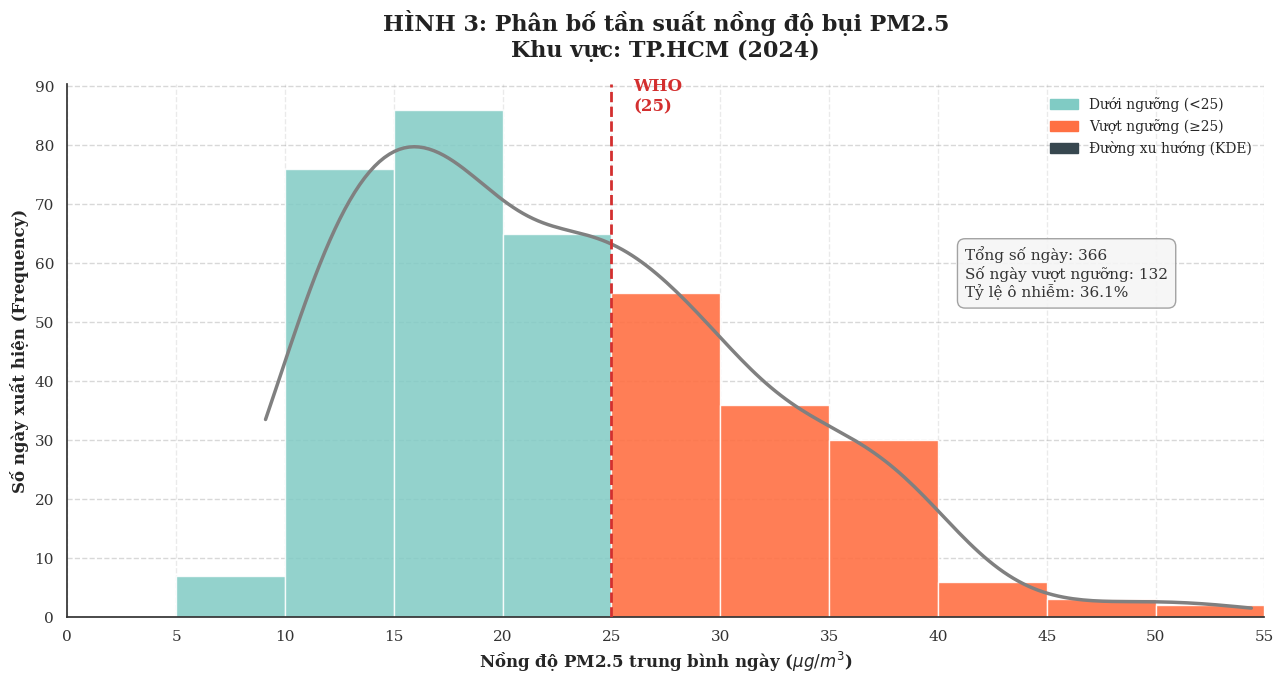

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator 
import os


os.makedirs('../figures', exist_ok=True)

if 'df_daily' not in locals() or df_daily.empty:
    print("❌ Lỗi: Chưa có dữ liệu df_daily.")
else:
         
    data = df_daily["pm2_5_mean"]
    threshold = 25  
    
    total_days = len(data)
    exceed_days = (data >= threshold).sum()
    exceed_ratio = exceed_days / total_days * 100
    max_val = int(np.ceil(data.max()))

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 12, 
        "axes.edgecolor": "#333333",
        "axes.spines.top": False,
        "axes.spines.right": False
    })

    bin_width = 5
    my_bins = np.arange(0, max_val + bin_width, bin_width)

    fig, ax = plt.subplots(figsize=(13, 7))

    sns.histplot(data, bins=my_bins, kde=True, color="gray", alpha=0, ax=ax, 
                 line_kws={'linewidth': 2.5, 'color': '#37474F'})

    n, bins, patches = ax.hist(data, bins=my_bins, color="gray", alpha=0)

    for patch in patches:
        x_center = patch.get_x() + patch.get_width() / 2
        if x_center < threshold:
            patch.set_facecolor('#80CBC4') 
            patch.set_edgecolor('white')
            patch.set_alpha(0.85)
        else:
            patch.set_facecolor('#FF7043') 
            patch.set_edgecolor('white')
            patch.set_alpha(0.9)

    ticks_x = np.arange(0, max_val + bin_width, 5) 
    ax.set_xticks(ticks_x) 
    ax.set_xlim(0, max_val)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

   
    ax.yaxis.set_major_locator(MultipleLocator(10))
    
    
    ax.grid(axis='y', linestyle='--', alpha=0.3, color='gray') 

    ax.axvline(threshold, color="#D32F2F", linestyle="--", linewidth=2, zorder=5)
    ax.text(threshold + 1, ax.get_ylim()[1] * 0.95, f"WHO\n({threshold})", 
            color="#D32F2F", fontweight="bold", ha="left")

    safe_patch = mpatches.Patch(color='#80CBC4', label='Dưới ngưỡng (<25)')
    danger_patch = mpatches.Patch(color='#FF7043', label='Vượt ngưỡng (≥25)')
    kde_line = mpatches.Patch(color='#37474F', label='Đường xu hướng (KDE)')
    ax.legend(handles=[safe_patch, danger_patch, kde_line], loc='upper right', frameon=False)

    stats_text = (
        f"Tổng số ngày: {total_days}\n"
        f"Số ngày vượt ngưỡng: {exceed_days}\n"
        f"Tỷ lệ ô nhiễm: {exceed_ratio:.1f}%"
    )
    ax.text(0.75, 0.60, stats_text, transform=ax.transAxes, fontsize=11, 
            color="#333333", bbox=dict(boxstyle="round,pad=0.5", facecolor="#F5F5F5", edgecolor="#999999", alpha=0.9))

    ax.set_title(f"HÌNH 3: Phân bố tần suất nồng độ bụi PM2.5\nKhu vực: {LOCATION} ({YEAR})",
                 fontsize=16, fontweight="bold", pad=20, color="#222222")
    ax.set_xlabel("Nồng độ PM2.5 trung bình ngày ($\mu g/m^3$)", fontweight="bold")
    ax.set_ylabel("Số ngày xuất hiện (Frequency)", fontweight="bold")

    plt.tight_layout()
    plt.savefig("../figures/03_Pm25_distribution.pdf", format="pdf", bbox_inches="tight")
    plt.show()
   

Hinh 4 monthly boxplot

C:\Users\Nguyen Duc Vu Bao\AppData\Local\Temp\ipykernel_14760\2504641752.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


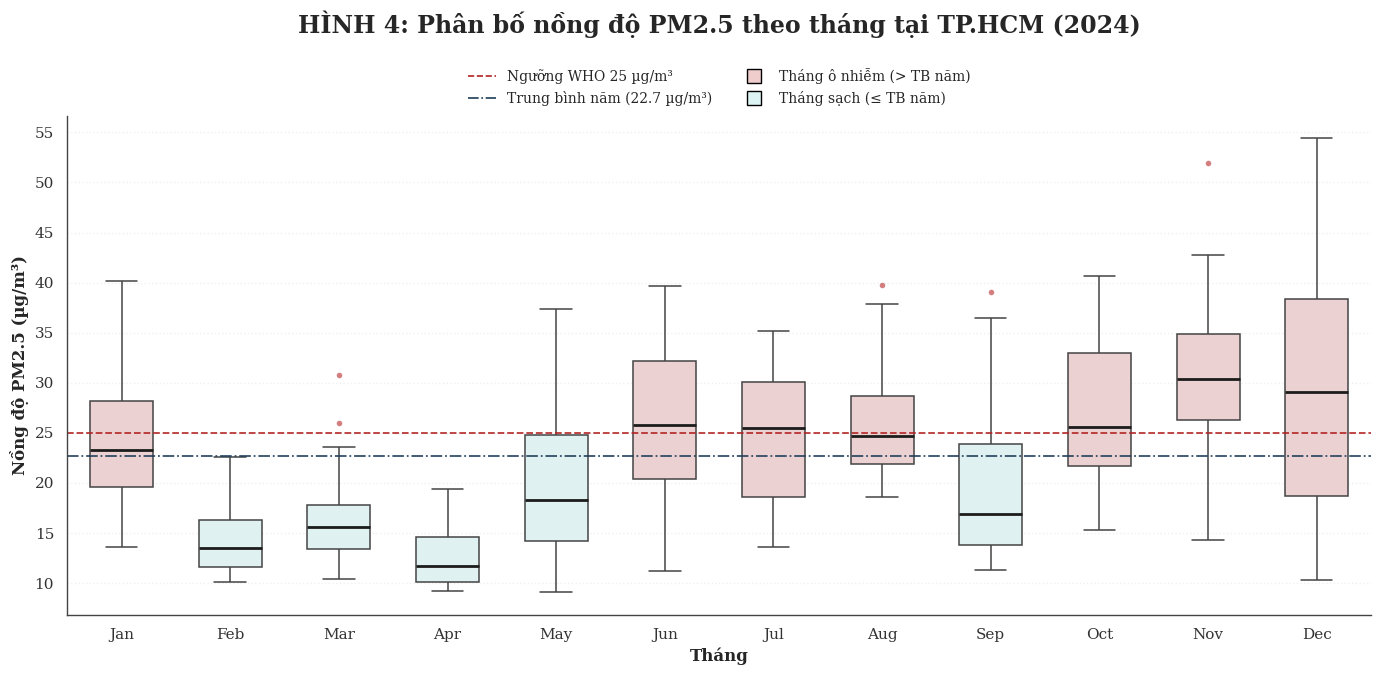

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D


plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 1,
})

if not df_daily.empty:

    
    if "month" not in df_daily.columns:
        df_daily["month"] = df_daily["date"].dt.month

   
    monthly_mean = df_daily.groupby("month")["pm2_5_mean"].mean()
    yearly_mean = df_daily["pm2_5_mean"].mean()

    polluted_months = monthly_mean[monthly_mean > yearly_mean].index.tolist()
    clean_months = monthly_mean[monthly_mean <= yearly_mean].index.tolist()

    
    colors = []
    for m in range(1, 13):
        if m in polluted_months:
            colors.append("#EFCDCD")   
        else:
            colors.append("#DCF4F3")   

    fig, ax = plt.subplots(figsize=(14, 7))

   
    sns.boxplot(
        data=df_daily,
        x="month",
        y="pm2_5_mean",
        ax=ax,
        palette=colors,
        width=0.58,
        linewidth=1.1,
        medianprops={"color": "#1C1C1C", "linewidth": 2},
        boxprops={"edgecolor": "#444"},
        whiskerprops={"color": "#444"},
        capprops={"color": "#444"},
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "#AA0000",
            "markeredgecolor": "none",
            "alpha": 0.5
        }
    )

   
    ax.axhline(25, color="#B22222", ls="--", lw=1.3, alpha=0.9)
    ax.axhline(yearly_mean, color="#1E3D59", ls="-.", lw=1.3, alpha=0.9)


    legend_elements = [
        Line2D([0], [0], color="#B22222", ls="--", lw=1.2,
               label="Ngưỡng WHO 25 µg/m³"),
        Line2D([0], [0], color="#1E3D59", ls="-.", lw=1.2,
               label=f"Trung bình năm ({yearly_mean:.1f} µg/m³)"),
        Line2D([0], [0], marker="s", color="none", markerfacecolor="#EFCDCD",
               markersize=10, label="Tháng ô nhiễm (> TB năm)"),
        Line2D([0], [0], marker="s", color="none", markerfacecolor="#DCF4F3",
               markersize=10, label="Tháng sạch (≤ TB năm)")
    ]

    ax.legend(handles=legend_elements,
              loc="upper center",
              bbox_to_anchor=(0.5, 1.12),
              ncol=2,
              frameon=False)

    
    ax.set_title(
        f"HÌNH 4: Phân bố nồng độ PM2.5 theo tháng tại {LOCATION} ({YEAR})",
        fontsize=17, fontweight="bold", y=1.15
    )
    ax.set_xlabel("Tháng", fontweight="bold")
    ax.set_ylabel("Nồng độ PM2.5 (µg/m³)", fontweight="bold")

    ax.yaxis.set_major_locator(MultipleLocator(5))
    ax.grid(axis="y", linestyle=":", alpha=0.3)

    ax.set_xticks(range(12))
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

    plt.tight_layout()
    plt.savefig("../figures/04_monthly_boxplot.pdf",
                dpi=300, bbox_inches="tight")
    plt.show()

else:
    print("❌ Không có dữ liệu.")


In [ ]:
Hình 5: Correlation Heatmap

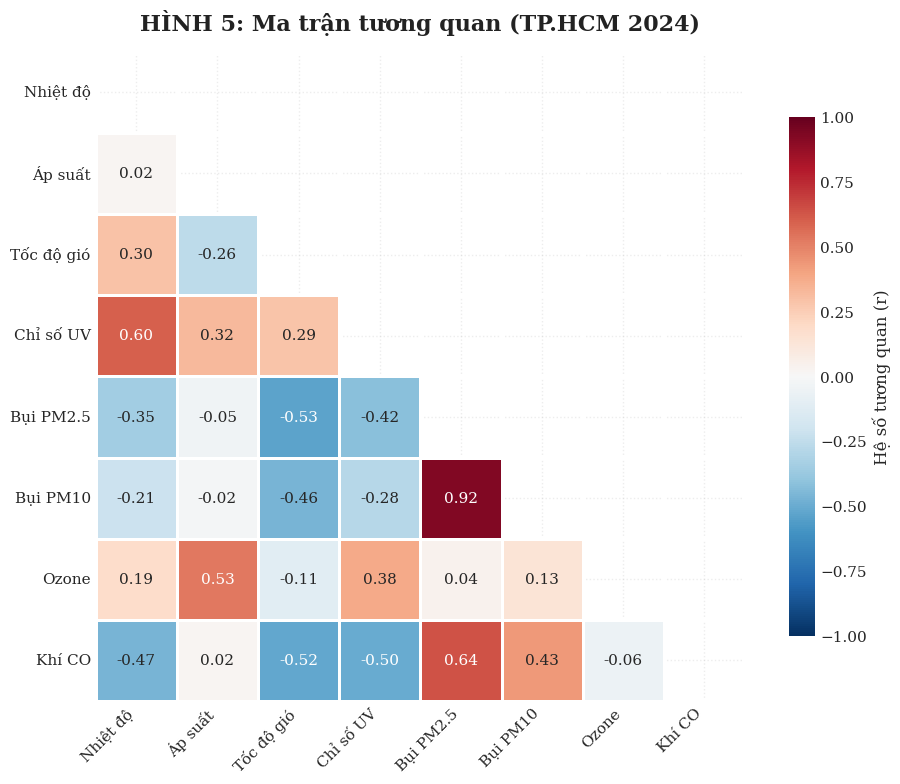

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- 1. CẤU HÌNH ---
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.edgecolor": "#333333"
})

if not df_daily.empty:
   
    potential_cols = [
        'temp_mean', 'pressure_mean', 'wind_speed_mean', 
        'uv_max', 'pm2_5_mean', 'pm10_mean', 'ozone_mean','co_mean'
    ]
    valid_cols = [c for c in potential_cols if c in df_daily.columns]

    if len(valid_cols) > 1:
        
        corr_matrix = df_daily[valid_cols].corr()

       
        rename_map = {
            'temp_mean': 'Nhiệt độ',
            'pressure_mean': 'Áp suất',
            'wind_speed_mean': 'Tốc độ gió',
            'uv_max': 'Chỉ số UV',
            'pm2_5_mean': 'Bụi PM2.5',
            'pm10_mean': 'Bụi PM10',
            'ozone_mean': 'Ozone',
            'co_mean': 'Khí CO',
        }
        corr_matrix_vn = corr_matrix.rename(index=rename_map, columns=rename_map)

        mask = np.triu(np.ones_like(corr_matrix_vn, dtype=bool))

      
        fig, ax = plt.subplots(figsize=(10, 8))

        sns.heatmap(corr_matrix_vn, 
                    mask=mask,        
                    annot=True,       
                    fmt=".2f", 
                    cmap='RdBu_r',    
                    center=0, vmin=-1, vmax=1,
                    square=True,      
                    linewidths=1, linecolor='white',
                    cbar_kws={"shrink": 0.8, "label": "Hệ số tương quan (r)"},
                    annot_kws={"size": 11},
                    ax=ax)

        ax.set_title(f'HÌNH 5: Ma trận tương quan ({LOCATION} {YEAR})', 
                     fontsize=16, fontweight='bold', y=1.02, color='#222222')
        
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)

        
        plt.tight_layout()
        plt.savefig("../figures/05_correlation_matrix.pdf", format="pdf", bbox_inches="tight")
        plt.show()
        

    else:
        print("⚠️ Không đủ dữ liệu.")
else:
    print("❌ Không có dữ liệu.")

In [ ]:
Hình 6: Scatter Plot

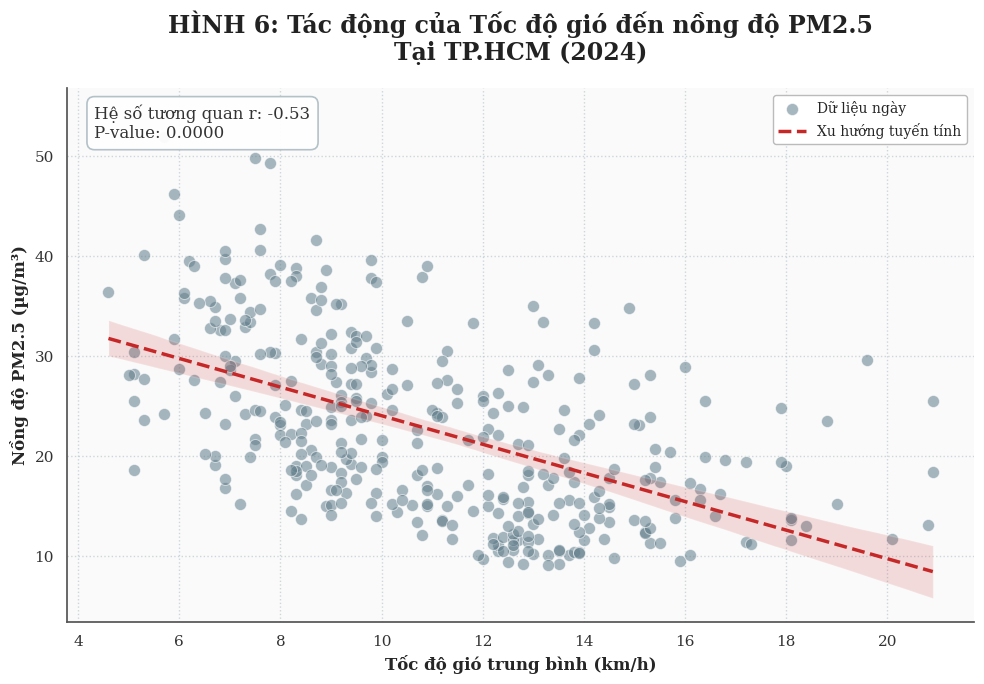

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats


plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.edgecolor": "#555555",
    "axes.spines.top": False,
    "axes.spines.right": False
})


COLOR_POINT = "#607D8B"      
COLOR_POINT_EDGE = "white"
COLOR_TREND = "#C62828"      
COLOR_GRID = "#B0BEC5"       
COLOR_BG = "#FAFAFA"        


if not df_daily.empty:
    

    if 'wind_speed_mean' in df_daily.columns and 'pm2_5_mean' in df_daily.columns:

        data_plot = df_daily[['wind_speed_mean', 'pm2_5_mean']].dropna()

        fig, ax = plt.subplots(figsize=(10, 7))
        ax.set_facecolor(COLOR_BG)

        sns.scatterplot(
            data=data_plot,
            x='wind_speed_mean', 
            y='pm2_5_mean',
            color=COLOR_POINT,
            alpha=0.55,
            s=75,
            edgecolor=COLOR_POINT_EDGE,
            linewidth=0.7,
            ax=ax,
            label="Dữ liệu ngày"
        )

        sns.regplot(
            data=data_plot,
            x='wind_speed_mean',
            y='pm2_5_mean',
            scatter=False,
            color=COLOR_TREND,
            line_kws={'linewidth': 2.5, 'linestyle': '--'},
            ax=ax,
            label="Xu hướng tuyến tính"
        )

        r, p_value = stats.pearsonr(data_plot['wind_speed_mean'], data_plot['pm2_5_mean'])
        
        stats_text = (
            f"Hệ số tương quan r: {r:.2f}\n"
            f"P-value: {p_value:.4f}"
        )

        ax.text(
            0.03, 0.97, stats_text,
            transform=ax.transAxes,
            fontsize=12,
            va='top',
            ha='left',
            color="#333333",
            bbox=dict(
                boxstyle='round,pad=0.45',
                facecolor='white',
                edgecolor='#B0BEC5',
                linewidth=1.2,
                alpha=0.95
            )
        )

        ax.set_title(
            f"HÌNH 6: Tác động của Tốc độ gió đến nồng độ PM2.5\nTại {LOCATION} ({YEAR})",
            fontsize=17,
            fontweight='bold',
            color="#222222",
            pad=20
        )

        ax.set_xlabel("Tốc độ gió trung bình (km/h)", fontweight='bold')
        ax.set_ylabel("Nồng độ PM2.5 (µg/m³)", fontweight='bold')
        ax.grid(True, linestyle=":", linewidth=1, color=COLOR_GRID, alpha=0.6)
        ax.tick_params(axis='both', which='major', length=6, width=1.2, color="#555555")
        ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="#BBBBBB")

        
        plt.tight_layout()
        plt.savefig("../figures/06_wind_pm25_scatter.pdf", format="pdf", dpi=300, bbox_inches="tight")
        plt.show()
        
    else:
        print("⚠️ Thiếu cột 'wind_speed_mean' hoặc 'pm2_5_mean'.")
else:
    print("❌ Không có dữ liệu.")


HÌNH 7: TƯƠNG QUAN NHIỆT ĐỘ - OZONE 

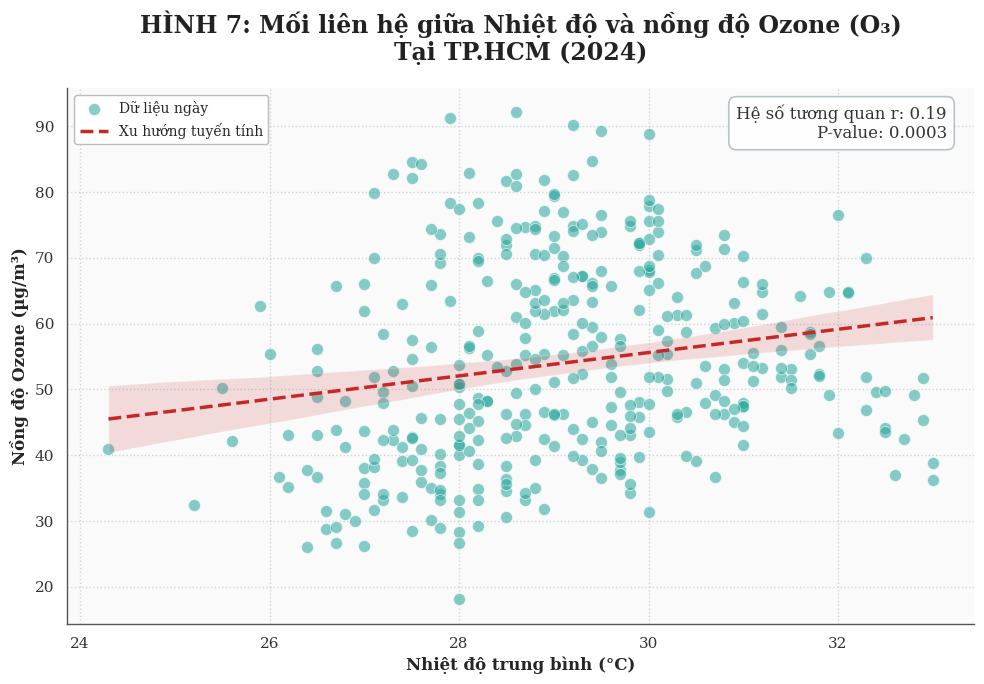

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats


plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.edgecolor": "#555555",
    "axes.spines.top": False,
    "axes.spines.right": False
})


o3_col = 'ozone_mean' if 'ozone_mean' in df_daily.columns else 'ozone_ugm3'

if o3_col in df_daily.columns:
   
    data_plot = df_daily[['temp_mean', o3_col]].dropna()
    r, p_value = stats.pearsonr(data_plot['temp_mean'], data_plot[o3_col]) 
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.set_facecolor("#FAFAFA")   # nền sáng dịu

    
    sns.scatterplot(
        data=data_plot,
        x='temp_mean', y=o3_col,
        color="#26A69A",       # xanh ngọc pastel
        alpha=0.55,
        s=75,
        edgecolor="white",
        linewidth=0.7,
        ax=ax,
        label="Dữ liệu ngày"
    )

    
    sns.regplot(
        data=data_plot,
        x='temp_mean', y=o3_col,
        scatter=False,
        color="#C62828",
        line_kws={'linewidth': 2.5, 'linestyle': '--'},
        ax=ax,
        label="Xu hướng tuyến tính"
    )

    
    stats_box = f"Hệ số tương quan r: {r:.2f}\nP-value: {p_value:.4f}"

    ax.text(
        0.97, 0.97, stats_box,
        transform=ax.transAxes,
        fontsize=12,
        ha='right', va='top',
        color="#333333",
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="white",
            edgecolor="#B0BEC5",
            linewidth=1.2,
            alpha=0.9
        )
    )

   
    ax.set_title(
        f"HÌNH 7: Mối liên hệ giữa Nhiệt độ và nồng độ Ozone (O₃)\nTại {LOCATION} ({YEAR})",
        fontsize=17,
        fontweight='bold',
        color="#222222",
        pad=20
    )

    ax.set_xlabel("Nhiệt độ trung bình (°C)", fontweight="bold")
    ax.set_ylabel("Nồng độ Ozone (µg/m³)", fontweight="bold")
    ax.grid(True, linestyle=":", linewidth=1, color="#B0BEC5", alpha=0.6)
    ax.tick_params(axis='both', which='major', length=6, width=1.2, color="#555555")
    ax.legend(frameon=True, facecolor="white", edgecolor="#BBBBBB")

    plt.tight_layout()
    plt.savefig("../figures/7_temp_ozone_scatter.pdf", format="pdf", dpi=300, bbox_inches="tight")
    plt.show()
    
else:
    print("⚠️ Không có dữ liệu.")


Hình 8: So sánh PM2.5 và PM10 (Tỷ lệ Bụi mịn/Bụi thô)

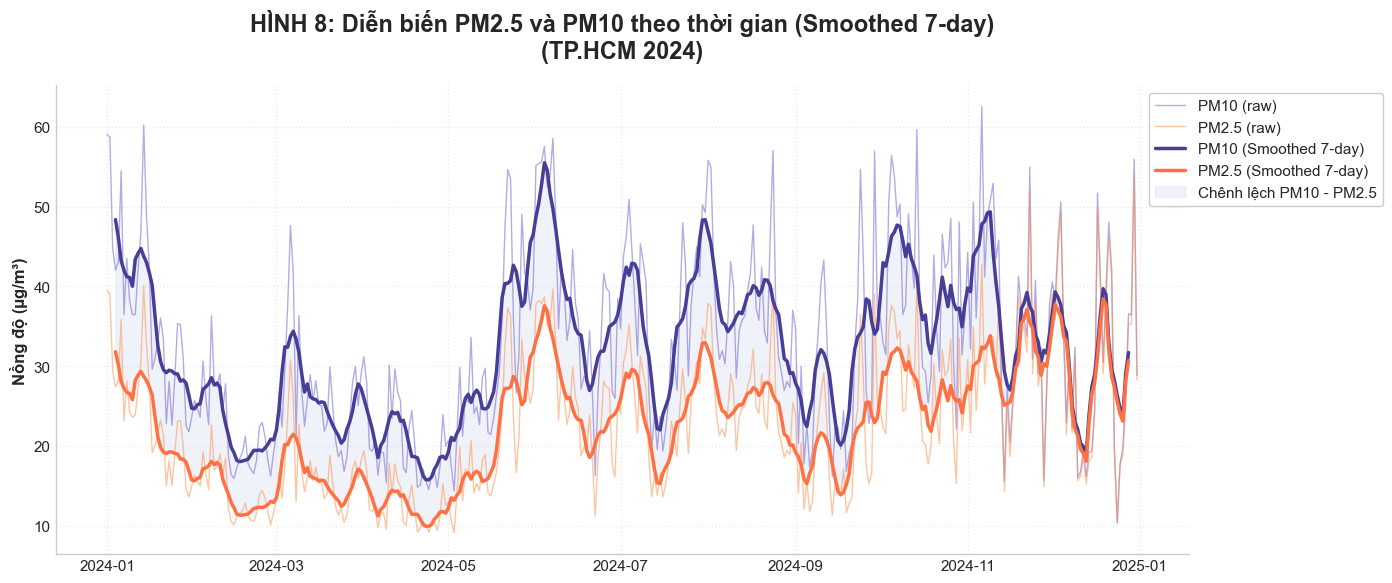

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")


if 'pm10_mean' in df_daily.columns and 'pm2_5_mean' in df_daily.columns:
    

    
    df_daily["pm25_smooth"] = df_daily["pm2_5_mean"].rolling(7, center=True).mean()
    df_daily["pm10_smooth"] = df_daily["pm10_mean"].rolling(7, center=True).mean()

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(df_daily['date'], df_daily['pm10_mean'],
            color="#6A5ACD", alpha=0.5, lw=1,
            label="PM10 (raw)")

    ax.plot(df_daily['date'], df_daily['pm2_5_mean'],
            color="#FF8C42", alpha=0.5, lw=1,
            label="PM2.5 (raw)")

    
    ax.plot(df_daily['date'], df_daily["pm10_smooth"],
            color="#473F97", lw=2.5,
            label="PM10 (Smoothed 7-day)")

    ax.plot(df_daily['date'], df_daily["pm25_smooth"],
            color="#FF7043", lw=2.5,
            label="PM2.5 (Smoothed 7-day)")

    
    ax.fill_between(
        df_daily['date'],
        df_daily["pm25_smooth"],
        df_daily["pm10_smooth"],
        where=(df_daily["pm10_smooth"] >= df_daily["pm25_smooth"]),
        color="#C7CEEA",
        alpha=0.25,
        label="Chênh lệch PM10 - PM2.5"
    )

   
    ax.set_title(
        f"HÌNH 8: Diễn biến PM2.5 và PM10 theo thời gian (Smoothed 7-day)\n({LOCATION} {YEAR})",
        fontsize=17, fontweight="bold",
        pad=20
    )

    ax.set_ylabel("Nồng độ (µg/m³)", fontweight="bold")
    ax.set_xlabel("")

   
    ax.legend(
        loc="upper right",
        bbox_to_anchor=(1.178, 1),
        frameon=True,
        fontsize=11
    )

    ax.grid(True, linestyle=":", alpha=0.4)

    plt.tight_layout()
    plt.savefig("../figures/8_pm25_vs_pm10_timeseries.pdf",
                format="pdf", bbox_inches="tight")
    plt.show()

    

else:
    print("⚠️ Không có dữ liệu .")


Hình 9: AQI CATEGORY STACKED BAR

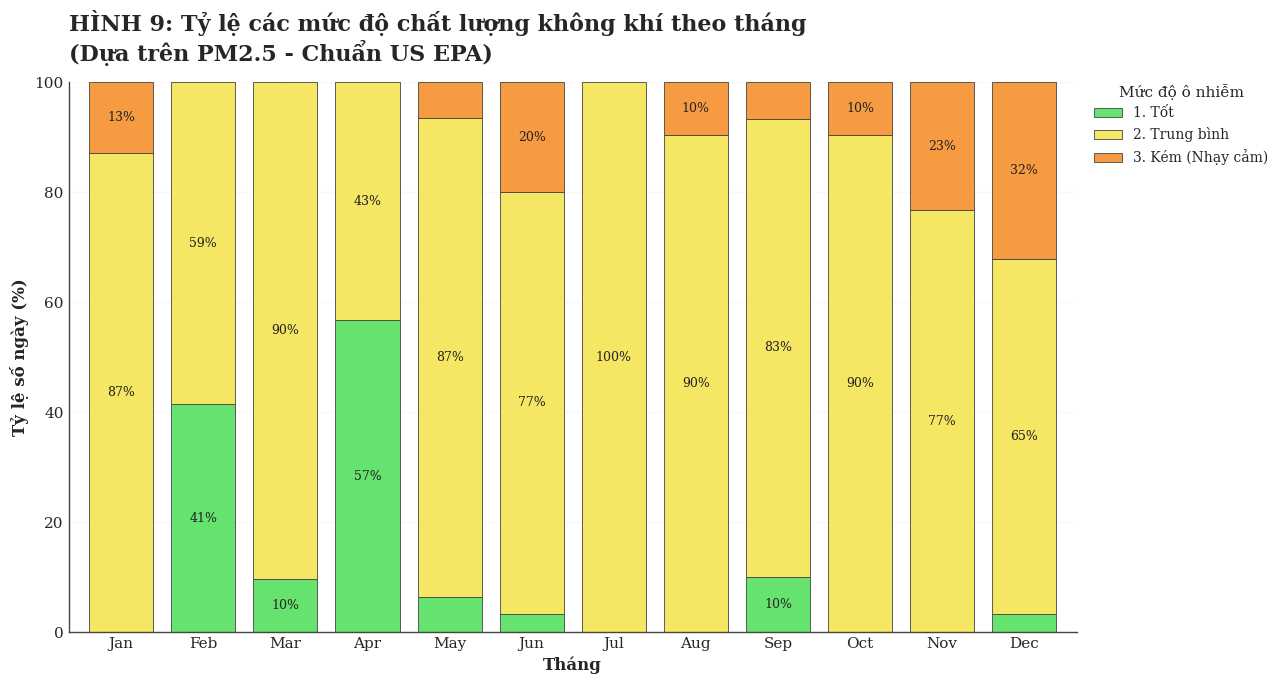

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.edgecolor": "#444444",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#cccccc",
    "grid.linestyle": ":",
    "grid.alpha": 0.35,
})

if not df_daily.empty:
    

    if 'month' not in df_daily.columns:
        df_daily['month'] = df_daily['date'].dt.month

    
    def categorize_pm25(pm):
        if pm <= 12.0: return '1. Tốt'
        elif pm <= 35.4: return '2. Trung bình'
        elif pm <= 55.4: return '3. Kém (Nhạy cảm)'
        elif pm <= 150.4: return '4. Xấu'
        else: return '5. Rất Xấu'

    df_daily['aqi_cat'] = df_daily['pm2_5_mean'].apply(categorize_pm25)

    
    monthly_counts = df_daily.groupby(['month', 'aqi_cat']).size().unstack(fill_value=0)
    monthly_props = monthly_counts.div(monthly_counts.sum(axis=1), axis=0) * 100

    
    aqi_colors = {
        '1. Tốt': '#66e26f',
        '2. Trung bình': '#f5e663',
        '3. Kém (Nhạy cảm)': '#f79b42',
        '4. Xấu': '#e0433e',
        '5. Rất Xấu': '#9b5bb2'
    }

    existing_cats = monthly_props.columns
    current_colors = [aqi_colors[c] for c in existing_cats]

    
    fig, ax = plt.subplots(figsize=(13, 7))

    monthly_props.plot(
        kind='bar',
        stacked=True,
        color=current_colors,
        edgecolor='#444444',
        linewidth=0.6,
        width=0.78,
        ax=ax
    )

    
    ax.set_title(
        "HÌNH 9: Tỷ lệ các mức độ chất lượng không khí theo tháng\n"
        "(Dựa trên PM2.5 - Chuẩn US EPA)",
        fontsize=16,
        fontweight="bold",
        loc='left',
        pad=15
    )

    ax.set_xlabel("Tháng", fontweight="bold")
    ax.set_ylabel("Tỷ lệ số ngày (%)", fontweight="bold")
    ax.set_ylim(0, 100)

    ax.set_xticklabels(
        ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
        rotation=0
    )

    
    ax.legend(
        title="Mức độ ô nhiễm",
        fontsize=10,
        title_fontsize=11,
        bbox_to_anchor=(1.005, 1.02),
        loc='upper left',
        frameon=False
    )

    
    for container in ax.containers:
        labels = [f"{v.get_height():.0f}%" if v.get_height() > 7 else "" for v in container]
        ax.bar_label(
            container,
            labels=labels,
            label_type='center',
            fontsize=9,
            color="#222222"
        )

    plt.tight_layout()
    plt.savefig("../figures/09_aqi_category_stacked_bar.pdf",
                format="pdf", bbox_inches="tight")
    plt.show()

    

else:
    print("❌ Không có dữ liệu.")
